## Name: Abhishek Chettiar



## Executive summary

- **Objective** — Rank applicants by default risk; maximize **ROC-AUC** with an **incremental multi-table** pipeline (one aggregated join at a time).
- **Data** — `application_train.csv` plus bureau, bureau_balance, previous_application, installments, POS_CASH, credit_card_balance; each rolled up **per `SK_ID_CURR`** (no raw many-to-one joins on applicants).
- **Approach** — EDA → multi-window aggregates (installments 90/180/365d; bureau/CC/POS 3–13mo + flags) → stratified holdout → **LightGBM** (gain pruning, shared params) → **K-fold ensemble** on full train → **`submission.csv`**.
- **Outcome** — **Restart & Run All**: incremental AUC table, validation metrics, full-train **LightGBM**, Kaggle-ready **`submission.csv`** (encoders fit on train only).
- **Key insight** — **Ratios** and **external scores** anchor the model; bureau and payment-behavior aggregates add complementary signal.

Concise ML report: explicit validation, reproducible code.



# Credit default risk — multi-table pipeline

**Home Credit** end-to-end experiment: predict **`TARGET`** from the current application plus **aggregated** related history. **Metric:** ROC-AUC. **Rules:** no SMOTE; stratified validation; **no direct many-to-one merge of raw subsidiary tables** (all child tables rolled up to one row per `SK_ID_CURR` first).



## Setup

Imports, reproducibility seeds, plot defaults. Uncomment `%pip` if packages are missing.



In [1]:
# %matplotlib inline
# %pip install -q pandas numpy matplotlib seaborn scikit-learn lightgbm

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier


In [2]:
RANDOM_STATE = 42
DATA_PATH = "application_train.csv"
PATH_TEST = "application_test.csv"
PATH_BUREAU = "bureau.csv"
PATH_BUREAU_BALANCE = "bureau_balance.csv"
PATH_PREVIOUS_APPLICATION = "previous_application.csv"
PATH_INSTALLMENTS = "installments_payments.csv"
PATH_POS_CASH = "POS_CASH_balance.csv"
PATH_CREDIT_CARD = "credit_card_balance.csv"
OHE_MAX_CATEGORIES = 15
MISS_DROP_THRESHOLD = 0.70
# Drop weakest fraction of features by LightGBM gain importances, then retrain (validation & final).
PRUNE_BOTTOM_FRAC = 0.06
# Stratified K-fold LightGBM models on the full train matrix; test predictions are averaged (no leakage).
N_FOLD_ENSEMBLE = 5

np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams.update(
    {
        "figure.figsize": (6.2, 3.0),
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.dpi": 115,
    }
)
pd.set_option("display.max_rows", 14)
pd.set_option("display.max_colwidth", 48)
pd.set_option("display.precision", 4)

ACCENT = "#2E86AB"
ACCENT2 = "#E94F37"


## Pipeline — constants & application feature engineering

Sentinel handling for Home Credit day-count fields and domain ratios on the application grain (**before** encoding).



### Application table — day sentinels

`365243` is treated as missing for elapsed-day fields before joins.


In [3]:
_SENTINEL = 365_243


def replace_day_sentinel(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Replace Home Credit sentinel (365243) with NaN for DAYS_* columns."""
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out.loc[out[c] == _SENTINEL, c] = np.nan
    return out


### Application table — domain ratios

Capacity, term, and external-score composites on the **current application** row.


In [4]:
def engineer_application_features(df: pd.DataFrame) -> pd.DataFrame:
    """Domain features on application grain (must run before encoding)."""
    out = df.copy()
    inc = out["AMT_INCOME_TOTAL"].replace(0, np.nan)
    credit = out["AMT_CREDIT"].replace(0, np.nan)
    ann = out["AMT_ANNUITY"].replace(0, np.nan)

    out["ANNUITY_INCOME_RATIO"] = out["AMT_ANNUITY"] / inc
    members = out["CNT_FAM_MEMBERS"].replace(0, np.nan)
    out["CHILDREN_RATIO"] = out["CNT_CHILDREN"] / members

    out["AGE_YEARS"] = -out["DAYS_BIRTH"] / 365.25
    out["EMPLOYMENT_YEARS"] = -out["DAYS_EMPLOYED"] / 365.25
    out["EMPLOYMENT_AGE_RATIO"] = out["EMPLOYMENT_YEARS"] / out["AGE_YEARS"].replace(0, np.nan)

    out["CREDIT_INCOME_RATIO"] = out["AMT_CREDIT"] / inc
    out["ANNUITY_CREDIT_RATIO"] = out["AMT_ANNUITY"] / credit
    out["CREDIT_TERM"] = out["AMT_CREDIT"] / ann

    ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    present = [c for c in ext_cols if c in out.columns]
    if present:
        out["EXT_SOURCE_MEAN"] = out[present].mean(axis=1)
        out["EXT_SOURCE_MIN"] = out[present].min(axis=1)
        out["EXT_SOURCE_MAX"] = out[present].max(axis=1)
        out["EXT_SOURCE_STD"] = out[present].std(axis=1)

    return out.replace([np.inf, -np.inf], np.nan)


## Pipeline — table aggregation functions

Each auxiliary table is aggregated to **one row per `SK_ID_CURR`** (or per `SK_ID_BUREAU` then rolled into bureau) before joining — **no** raw many-to-one merges onto applicants.



In [5]:
from __future__ import annotations


def _months_recent_mask(months_balance: pd.Series, last_n: int) -> pd.Series:
    """Months-of-balance relative to application (0 = current month, -1 = prior, ...)."""
    return months_balance >= -last_n


In [6]:
def aggregate_bureau_balance(bureau_balance: pd.DataFrame) -> pd.DataFrame:
    """One row per SK_ID_BUREAU — full history aggregates + recent windows + recency weights."""
    bb = bureau_balance.copy()
    if bb.empty or "SK_ID_BUREAU" not in bb.columns:
        return pd.DataFrame(columns=["SK_ID_BUREAU"])

    if "MONTHS_BALANCE" in bb.columns:
        bb["MONTHS_BALANCE_NEG"] = -bb["MONTHS_BALANCE"]
    if "STATUS" in bb.columns:
        bb["STATUS_NUM"] = pd.to_numeric(bb["STATUS"], errors="coerce")

    num_cols = [
        c
        for c in bb.select_dtypes(include=[np.number]).columns
        if c != "SK_ID_BUREAU"
    ]
    if num_cols:
        agg_dict = {c: ["mean", "max", "min", "sum", "count", "std"] for c in num_cols}
        g_base = bb.groupby("SK_ID_BUREAU").agg(agg_dict)
        g_base.columns = ["BB_" + "_".join(col).strip() for col in g_base.columns.values]
        g_base = g_base.reset_index()
    else:
        g_base = pd.DataFrame({"SK_ID_BUREAU": bb["SK_ID_BUREAU"].unique()})

    extra_rows: list[dict] = []
    for bid, gx in bb.groupby("SK_ID_BUREAU"):
        er: dict = {"SK_ID_BUREAU": bid}
        mb = gx["MONTHS_BALANCE"] if "MONTHS_BALANCE" in gx.columns else None
        if mb is not None and len(gx):
            rw = np.exp(np.clip(mb.astype(float).to_numpy(), -96.0, 0.0) / 20.0)
            if "STATUS_NUM" in gx.columns:
                sn = gx["STATUS_NUM"].astype(float).to_numpy()
                wsum = np.nansum(sn * rw)
                wden = np.nansum(rw)
                er["BB_RECENCY_WMEAN_STATUS"] = float(wsum / wden) if wden > 0 else np.nan
            else:
                er["BB_RECENCY_WMEAN_STATUS"] = np.nan
        else:
            er["BB_RECENCY_WMEAN_STATUS"] = np.nan

        for wm in (3, 6, 12, 13):
            pre = f"BB_W{wm}_"
            if mb is None:
                er[f"{pre}CNT"] = 0
                er[f"{pre}STATUS_MEAN"] = np.nan
                er[f"{pre}DELINQ_SHARE"] = np.nan
                continue
            sub = gx.loc[_months_recent_mask(mb, wm)]
            er[f"{pre}CNT"] = int(len(sub))
            if len(sub) and "STATUS_NUM" in sub.columns:
                er[f"{pre}STATUS_MEAN"] = float(sub["STATUS_NUM"].mean())
                er[f"{pre}DELINQ_SHARE"] = float((sub["STATUS_NUM"].fillna(0) > 1).mean())
            else:
                er[f"{pre}STATUS_MEAN"] = np.nan
                er[f"{pre}DELINQ_SHARE"] = np.nan
        extra_rows.append(er)

    extra_df = pd.DataFrame(extra_rows)
    return g_base.merge(extra_df, on="SK_ID_BUREAU", how="left")


In [7]:
def aggregate_bureau(bureau: pd.DataFrame, bb_per_bureau: pd.DataFrame | None) -> pd.DataFrame:
    """Aggregate bureau (+ optional bureau_balance rollups) per applicant."""
    bu = replace_day_sentinel(
        bureau,
        [c for c in bureau.columns if "DAYS" in c.upper()],
    )

    if bb_per_bureau is not None and len(bb_per_bureau):
        bu = bu.merge(bb_per_bureau, on="SK_ID_BUREAU", how="left")

    num_for_agg = [
        c
        for c in bu.select_dtypes(include=[np.number]).columns
        if c not in ("SK_ID_CURR", "SK_ID_BUREAU")
    ]

    agg_dict = {}
    for c in num_for_agg:
        agg_dict[c] = ["mean", "max", "min", "sum", "count", "std"]

    g = bu.groupby("SK_ID_CURR").agg(agg_dict)
    g.columns = ["BURO_" + "_".join(col).strip() for col in g.columns.values]
    g = g.reset_index()

    if "CREDIT_ACTIVE" in bu.columns:
        active_dummies = pd.get_dummies(bu["CREDIT_ACTIVE"], prefix="BURO_ACTIVE")
        active_dummies["SK_ID_CURR"] = bu["SK_ID_CURR"].values
        active_sum = active_dummies.groupby("SK_ID_CURR").sum()
        active_sum = active_sum.add_prefix("BURO_CNT_ACTIVE_").reset_index()
        g = g.merge(active_sum, on="SK_ID_CURR", how="left")

    if "CREDIT_TYPE" in bu.columns:
        n_types = bu.groupby("SK_ID_CURR")["CREDIT_TYPE"].nunique().rename("BURO_N_CREDIT_TYPES")
        g = g.merge(n_types.reset_index(), on="SK_ID_CURR", how="left")

    return g




In [8]:
def aggregate_previous_application(prev: pd.DataFrame) -> pd.DataFrame:
    """Previous applications per current applicant (+ decision ratios)."""
    p = replace_day_sentinel(prev, [c for c in prev.columns if "DAYS" in c.upper()])

    num_cols = [
        c
        for c in p.select_dtypes(include=[np.number]).columns
        if c not in ("SK_ID_CURR", "SK_ID_PREV")
    ]
    agg_dict = {c: ["mean", "max", "min", "sum", "count", "std"] for c in num_cols}
    gg = p.groupby("SK_ID_CURR").agg(agg_dict)
    gg.columns = ["PREV_" + "_".join(col).strip() for col in gg.columns.values]
    g = gg.reset_index()

    if "NAME_CONTRACT_STATUS" in p.columns:
        appr = (
            (p["NAME_CONTRACT_STATUS"] == "Approved").astype(np.float32).groupby(p["SK_ID_CURR"]).mean()
        )
        g = g.merge(appr.rename("PREV_APPROVED_RATE").reset_index(), on="SK_ID_CURR", how="left")
        refused = (
            (p["NAME_CONTRACT_STATUS"] == "Refused").astype(np.float32).groupby(p["SK_ID_CURR"]).mean()
        )
        g = g.merge(refused.rename("PREV_REFUSED_RATE").reset_index(), on="SK_ID_CURR", how="left")

        appr_n = (p["NAME_CONTRACT_STATUS"] == "Approved").astype(np.int32).groupby(p["SK_ID_CURR"]).sum()
        ref_n = (p["NAME_CONTRACT_STATUS"] == "Refused").astype(np.int32).groupby(p["SK_ID_CURR"]).sum()
        decided = (appr_n + ref_n).replace(0, np.nan)
        g = g.merge((appr_n / decided).rename("PREV_APPROVED_AMONG_DECIDED").reset_index(), on="SK_ID_CURR", how="left")
        g = g.merge((ref_n / decided).rename("PREV_REFUSED_AMONG_DECIDED").reset_index(), on="SK_ID_CURR", how="left")
        g = g.merge((ref_n > 0).astype(np.float32).rename("PREV_HAS_REFUSAL").reset_index(), on="SK_ID_CURR", how="left")

        if "Canceled" in p["NAME_CONTRACT_STATUS"].unique():
            canc = (
                (p["NAME_CONTRACT_STATUS"] == "Canceled").astype(np.float32).groupby(p["SK_ID_CURR"]).mean()
            )
            g = g.merge(canc.rename("PREV_CANCELED_RATE").reset_index(), on="SK_ID_CURR", how="left")

    if "FLAG_LAST_APPL_PER_CONTRACT" in p.columns:
        last_y = (
            (p["FLAG_LAST_APPL_PER_CONTRACT"] == "Y").astype(np.float32).groupby(p["SK_ID_CURR"]).mean()
        )
        g = g.merge(last_y.rename("PREV_LAST_APPL_PER_CONTRACT_RATE").reset_index(), on="SK_ID_CURR", how="left")

    return g




### Installments — time windows

Recent **90 / 180 / 365**-day slices on DAYS_INSTALMENT before the global per-applicant stats.


In [9]:
def _installments_window_agg(ins: pd.DataFrame, days: int, prefix: str) -> pd.DataFrame:
    if ins.empty or "SK_ID_CURR" not in ins.columns:
        return pd.DataFrame(columns=["SK_ID_CURR"])
    if "DAYS_INSTALMENT" not in ins.columns:
        return pd.DataFrame(columns=["SK_ID_CURR"])
    sub = ins[ins["DAYS_INSTALMENT"] > -days]
    if sub.empty:
        return pd.DataFrame(columns=["SK_ID_CURR"])
    num_cols = [
        c
        for c in sub.select_dtypes(include=[np.number]).columns
        if c not in ("SK_ID_CURR", "SK_ID_PREV") and not str(c).startswith("_")
    ]
    if not num_cols:
        cnt = sub.groupby("SK_ID_CURR").size().rename(f"{prefix}CNT")
        return cnt.reset_index()
    agg_dict = {c: ["mean", "sum", "max"] for c in num_cols}
    agg = sub.groupby("SK_ID_CURR").agg(agg_dict)
    agg.columns = [prefix + "_".join(col).strip() for col in agg.columns.values]
    return agg.reset_index()


### Installments — behavioral aggregates

Late-payment flags, ratios, recency-weighted delay, and window merges.


In [10]:
def aggregate_installments(inst: pd.DataFrame) -> pd.DataFrame:
    """Payment delay / installment behavior — behavioral rates, recent-day windows, recency weights."""
    ins = replace_day_sentinel(inst, [c for c in inst.columns if "DAYS" in c.upper()])
    if {"DAYS_ENTRY_PAYMENT", "DAYS_INSTALMENT"}.issubset(ins.columns):
        ins["INST_PAYMENT_DIFF"] = ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"]
        ins["INST_PAYMENT_DIFF_POS"] = ins["INST_PAYMENT_DIFF"].clip(lower=0)
        ins["INST_IS_LATE"] = (ins["INST_PAYMENT_DIFF"] > 0).astype(np.float32)
        ins["INST_IS_SEVERE_LATE"] = (ins["INST_PAYMENT_DIFF"] > 30).astype(np.float32)
    if {"AMT_PAYMENT", "AMT_INSTALMENT"}.issubset(ins.columns):
        denom = ins["AMT_INSTALMENT"].replace(0, np.nan)
        ins["INST_PAYMENT_RATIO"] = ins["AMT_PAYMENT"] / denom

    if "INST_PAYMENT_DIFF_POS" in ins.columns and "DAYS_INSTALMENT" in ins.columns:
        d = ins["DAYS_INSTALMENT"].astype(float)
        ins["_REC_W"] = np.exp(np.clip(d.to_numpy(), -8000.0, 0.0) / 450.0)

    num_cols = [
        c
        for c in ins.select_dtypes(include=[np.number]).columns
        if c not in ("SK_ID_CURR", "SK_ID_PREV") and not str(c).startswith("_")
    ]
    agg_dict = {c: ["mean", "max", "min", "sum", "count", "std"] for c in num_cols}
    g = ins.groupby("SK_ID_CURR").agg(agg_dict)
    g.columns = ["INST_" + "_".join(col).strip() for col in g.columns.values]
    g = g.reset_index()

    if "INST_IS_LATE" in ins.columns:
        lr = ins.groupby("SK_ID_CURR")["INST_IS_LATE"].mean().rename("INST_LATE_PAYMENT_RATE")
        g = g.merge(lr.reset_index(), on="SK_ID_CURR", how="left")
    if "INST_IS_SEVERE_LATE" in ins.columns:
        sr = ins.groupby("SK_ID_CURR")["INST_IS_SEVERE_LATE"].mean().rename("INST_SEVERE_LATE_PAYMENT_RATE")
        g = g.merge(sr.reset_index(), on="SK_ID_CURR", how="left")

    if "_REC_W" in ins.columns and "INST_PAYMENT_DIFF_POS" in ins.columns:
        num = (ins["INST_PAYMENT_DIFF_POS"].fillna(0) * ins["_REC_W"]).groupby(ins["SK_ID_CURR"]).sum()
        den = ins["_REC_W"].groupby(ins["SK_ID_CURR"]).sum()
        rw = (num / den.replace(0, np.nan)).rename("INST_RECENCY_WMEAN_LATE_DAYS")
        g = g.merge(rw.reset_index(), on="SK_ID_CURR", how="left")

    for dwin, lab in ((90, "INST_W90_"), (180, "INST_W180_"), (365, "INST_W365_")):
        w = _installments_window_agg(ins, dwin, lab)
        if len(w):
            g = g.merge(w, on="SK_ID_CURR", how="left")

    return g




In [11]:
def _balance_table_window_agg(
    df: pd.DataFrame,
    prefix: str,
    months: int,
    id_col: str,
) -> pd.DataFrame:
    if df.empty or "MONTHS_BALANCE" not in df.columns:
        return pd.DataFrame(columns=[id_col])
    sub = df.loc[_months_recent_mask(df["MONTHS_BALANCE"], months)]
    if sub.empty:
        return pd.DataFrame(columns=[id_col])
    num_cols = [
        c
        for c in sub.select_dtypes(include=[np.number]).columns
        if c not in (id_col, "SK_ID_PREV") and not str(c).startswith("_")
    ]
    if not num_cols:
        cnt = sub.groupby(id_col).size().rename(f"{prefix}W{months}_CNT")
        return cnt.reset_index()
    agg_dict = {c: ["mean", "max", "sum"] for c in num_cols}
    agg = sub.groupby(id_col).agg(agg_dict)
    agg.columns = [f"{prefix}W{months}_" + "_".join(col).strip() for col in agg.columns.values]
    return agg.reset_index()


In [12]:
def aggregate_pos_cash(pos: pd.DataFrame) -> pd.DataFrame:
    """POS cash balances — utilization-style signals, DPD frequency, windows, recency."""
    p = replace_day_sentinel(pos, [c for c in pos.columns if "DAYS" in c.upper() or c.startswith("SK_DPD")])

    if "SK_DPD" in p.columns:
        p["POS_DPD_POS"] = (p["SK_DPD"].fillna(0) > 0).astype(np.float32)

    num_cols = [
        c
        for c in p.select_dtypes(include=[np.number]).columns
        if c not in ("SK_ID_CURR", "SK_ID_PREV") and not str(c).startswith("_")
    ]
    agg_dict = {c: ["mean", "max", "min", "sum", "count", "std"] for c in num_cols}
    g = p.groupby("SK_ID_CURR").agg(agg_dict)
    g.columns = ["POS_" + "_".join(col).strip() for col in g.columns.values]
    g = g.reset_index()

    if "POS_DPD_POS" in p.columns:
        dr = p.groupby("SK_ID_CURR")["POS_DPD_POS"].mean().rename("POS_DELINQ_FREQ")
        g = g.merge(dr.reset_index(), on="SK_ID_CURR", how="left")

    if "MONTHS_BALANCE" in p.columns:
        mb = p["MONTHS_BALANCE"].astype(float)
        rw = np.exp(np.clip(mb.to_numpy(), -96.0, 0.0) / 20.0)
        p = p.copy()
        p["_REC_W"] = rw
        if "SK_DPD" in p.columns:
            x = p["SK_DPD"].fillna(0).astype(float)
            num = (x * p["_REC_W"]).groupby(p["SK_ID_CURR"]).sum()
            den = p["_REC_W"].groupby(p["SK_ID_CURR"]).sum()
            rwm = (num / den.replace(0, np.nan)).rename("POS_RECENCY_WMEAN_DPD")
            g = g.merge(rwm.reset_index(), on="SK_ID_CURR", how="left")

    for wm in (3, 6, 12, 13):
        w = _balance_table_window_agg(p, "POS_", wm, "SK_ID_CURR")
        if len(w):
            g = g.merge(w, on="SK_ID_CURR", how="left")

    if "SK_DPD" in p.columns:
        mx = p.groupby("SK_ID_CURR")["SK_DPD"].max().rename("POS_MAX_SK_DPD")
        g = g.merge(mx.reset_index(), on="SK_ID_CURR", how="left")
        any_del = (p.groupby("SK_ID_CURR")["SK_DPD"].max() > 0).astype(np.float32).rename("POS_ANY_HIST_DELINQ")
        g = g.merge(any_del.reset_index(), on="SK_ID_CURR", how="left")

    return g


In [13]:
def aggregate_credit_card(cc: pd.DataFrame) -> pd.DataFrame:
    """Credit card monthly snapshots — utilization stress, DPD frequency, windows, recency."""
    c = cc.copy()
    if {"AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL"}.issubset(c.columns):
        lim = c["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
        c["CC_UTILIZATION"] = c["AMT_BALANCE"] / lim

    if "CC_UTILIZATION" in c.columns:
        c["CC_HIGH_UTIL"] = (c["CC_UTILIZATION"] > 0.9).astype(np.float32)
    if "SK_DPD" in c.columns:
        c["CC_DPD_POS"] = (c["SK_DPD"].fillna(0) > 0).astype(np.float32)

    num_cols = [
        col
        for col in c.select_dtypes(include=[np.number]).columns
        if col not in ("SK_ID_CURR", "SK_ID_PREV") and not str(col).startswith("_")
    ]
    agg_dict = {col: ["mean", "max", "min", "sum", "count", "std"] for col in num_cols}
    g = c.groupby("SK_ID_CURR").agg(agg_dict)
    g.columns = ["CC_" + "_".join(col).strip() for col in g.columns.values]
    g = g.reset_index()

    if "CC_HIGH_UTIL" in c.columns:
        hu = c.groupby("SK_ID_CURR")["CC_HIGH_UTIL"].mean().rename("CC_HIGH_UTILIZATION_FREQ")
        g = g.merge(hu.reset_index(), on="SK_ID_CURR", how="left")
    if "CC_UTILIZATION" in c.columns:
        u80 = (c["CC_UTILIZATION"] > 0.8).astype(np.float32).groupby(c["SK_ID_CURR"]).mean().rename(
            "CC_UTIL_OVER80_FREQ"
        )
        g = g.merge(u80.reset_index(), on="SK_ID_CURR", how="left")
        any80 = (c.groupby("SK_ID_CURR")["CC_UTILIZATION"].max() > 0.8).astype(np.float32).rename(
            "CC_ANY_UTIL_OVER80"
        )
        g = g.merge(any80.reset_index(), on="SK_ID_CURR", how="left")
    if "CC_DPD_POS" in c.columns:
        dq = c.groupby("SK_ID_CURR")["CC_DPD_POS"].mean().rename("CC_DELINQ_FREQ")
        g = g.merge(dq.reset_index(), on="SK_ID_CURR", how="left")

    if "MONTHS_BALANCE" in c.columns and "CC_UTILIZATION" in c.columns:
        mb = c["MONTHS_BALANCE"].astype(float)
        rw = np.exp(np.clip(mb.to_numpy(), -96.0, 0.0) / 20.0)
        cc2 = c.copy()
        cc2["_REC_W"] = rw
        u = cc2["CC_UTILIZATION"].replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
        num = (u * cc2["_REC_W"]).groupby(cc2["SK_ID_CURR"]).sum()
        den = cc2["_REC_W"].groupby(cc2["SK_ID_CURR"]).sum()
        rwm = (num / den.replace(0, np.nan)).rename("CC_RECENCY_WMEAN_UTIL")
        g = g.merge(rwm.reset_index(), on="SK_ID_CURR", how="left")

    for wm in (3, 6, 12, 13):
        w = _balance_table_window_agg(c, "CC_", wm, "SK_ID_CURR")
        if len(w):
            g = g.merge(w, on="SK_ID_CURR", how="left")

    return g



## Pipeline — merging stages

`merge_stage` joins progressively richer aggregated blocks. Use **`full`** for the competition feature set.



In [14]:
from __future__ import annotations

def merge_stage(
    app: pd.DataFrame,
    stage: str,
    *,
    bureau: pd.DataFrame | None = None,
    bureau_balance: pd.DataFrame | None = None,
    previous_application: pd.DataFrame | None = None,
    installments_payments: pd.DataFrame | None = None,
    pos_cash_balance: pd.DataFrame | None = None,
    credit_card_balance: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Left-merge aggregated tables through the requested stage."""
    out = app.copy()
    if stage in ("app", "application"):
        return out

    if stage in ("bureau", "previous", "installments", "pos_cash", "credit_card", "full"):
        bb_agg = aggregate_bureau_balance(bureau_balance) if bureau_balance is not None else None
        bu_agg = aggregate_bureau(bureau, bb_agg) if bureau is not None else None
        if bu_agg is not None:
            out = out.merge(bu_agg, on="SK_ID_CURR", how="left")

    if stage in ("previous", "installments", "pos_cash", "credit_card", "full"):
        prev_agg = aggregate_previous_application(previous_application) if previous_application is not None else None
        if prev_agg is not None:
            out = out.merge(prev_agg, on="SK_ID_CURR", how="left")

    if stage in ("installments", "pos_cash", "credit_card", "full"):
        ins_agg = aggregate_installments(installments_payments) if installments_payments is not None else None
        if ins_agg is not None:
            out = out.merge(ins_agg, on="SK_ID_CURR", how="left")

    if stage in ("pos_cash", "credit_card", "full"):
        pos_agg = aggregate_pos_cash(pos_cash_balance) if pos_cash_balance is not None else None
        if pos_agg is not None:
            out = out.merge(pos_agg, on="SK_ID_CURR", how="left")

    if stage in ("credit_card", "full"):
        cc_agg = aggregate_credit_card(credit_card_balance) if credit_card_balance is not None else None
        if cc_agg is not None:
            out = out.merge(cc_agg, on="SK_ID_CURR", how="left")

    return out



## Pipeline — design matrix, evaluation, incremental study

`dataframe_to_design_matrix` mirrors the baseline preprocessing (drop sparse columns, missing flags, medians, OHE).

`DesignMatrixPreprocessor` fits **only on training data** and transforms **`application_test`** with aligned columns — no test-label leakage.



### Design matrix — utilities

Small helpers keep the preprocessor readable; **fit** learns medians/encoders on train only.


In [15]:
from __future__ import annotations

_MISSING_INDICATOR_COLS = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "OCCUPATION_TYPE",
]


def _dmp_add_missing_indicators(frame: pd.DataFrame, cols: list[str]) -> None:
    for col in cols:
        if col in frame.columns:
            frame[f"{col}_was_missing"] = frame[col].isna().astype(np.int8)


def _dmp_fill_categorical_inplace(frame: pd.DataFrame, cat_cols: list[str]) -> None:
    for c in cat_cols:
        if frame[c].dtype.name == "category":
            if "Unknown" not in frame[c].cat.categories:
                frame[c] = frame[c].cat.add_categories(["Unknown"])
            frame[c] = frame[c].fillna("Unknown")
        else:
            frame[c] = frame[c].fillna("Unknown")


def _dmp_fill_categorical_features_inplace(features: pd.DataFrame, cat_cols: list[str]) -> None:
    for c in cat_cols:
        if features[c].dtype.name == "category":
            if "Unknown" not in features[c].cat.categories:
                try:
                    features[c] = features[c].cat.add_categories(["Unknown"])
                except (TypeError, ValueError):
                    features[c] = features[c].astype(str)
            features[c] = features[c].fillna("Unknown")
        else:
            features[c] = features[c].fillna("Unknown")


### Design matrix — encoding & stacking

High-card label maps, **one-hot** for low-cardinality columns, and the final **float32** block.


In [16]:
def _dmp_apply_label_encoders_inplace(x_enc: pd.DataFrame, high_card: list[str], encoders: dict[str, LabelEncoder]) -> None:
    for c in high_card:
        le = encoders[c]
        classes = list(le.classes_)
        unk = len(classes)
        mapping = {lab: i for i, lab in enumerate(classes)}
        x_enc[c] = (
            x_enc[c]
            .astype(str)
            .map(lambda x, mapping=mapping, unk=unk: mapping.get(x, unk))
            .astype(np.float32)
        )


def _dmp_make_ohe() -> OneHotEncoder | None:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def _dmp_hstack_numeric_ohe(
    x_enc: pd.DataFrame,
    num_cols: list[str],
    high_card: list[str],
    low_card: list[str],
    ohe: OneHotEncoder | None,
) -> np.ndarray:
    numeric_block = x_enc[num_cols + high_card].to_numpy(dtype=np.float32)
    if low_card and ohe is not None:
        ohe_matrix = ohe.transform(x_enc[low_card])
        ohe_f32 = np.asarray(ohe_matrix, dtype=np.float32)
        return np.hstack([numeric_block, ohe_f32])
    return numeric_block


### Design matrix — `DesignMatrixPreprocessor`

Fit on train, then `transform` test with the **same** column set and imputations.


In [17]:
class DesignMatrixPreprocessor:
    """Fit preprocessing on train; transform train or test with identical feature space."""

    def __init__(self, ohe_max_categories: int = 15, miss_drop_threshold: float = 0.70):
        self.ohe_max_categories = ohe_max_categories
        self.miss_drop_threshold = miss_drop_threshold

    def fit(self, df: pd.DataFrame) -> "DesignMatrixPreprocessor":
        frame = df.replace([np.inf, -np.inf], np.nan)

        miss_frac = frame.isna().mean()
        self.drop_cols_ = [
            c
            for c in miss_frac[miss_frac > self.miss_drop_threshold].index
            if c not in ("TARGET", "SK_ID_CURR")
        ]
        frame = frame.drop(columns=self.drop_cols_, errors="ignore")

        _dmp_add_missing_indicators(frame, _MISSING_INDICATOR_COLS)

        if "TARGET" not in frame.columns:
            raise ValueError("Training frame must contain TARGET.")

        self.y_ = frame["TARGET"].astype(int).to_numpy()
        features = frame.drop(columns=["TARGET"])
        if "SK_ID_CURR" in features.columns:
            features = features.drop(columns=["SK_ID_CURR"])

        self.raw_columns_ = features.columns.tolist()

        self.cat_cols_ = features.select_dtypes(include=["category", "object"]).columns.tolist()
        self.num_cols_ = features.select_dtypes(include=[np.number]).columns.tolist()

        self.medians_ = {}
        for c in self.num_cols_:
            m = features[c].median()
            self.medians_[c] = 0.0 if pd.isna(m) else float(m)

        filled = features.copy()
        for c in self.num_cols_:
            filled[c] = filled[c].fillna(self.medians_[c]).replace([np.inf, -np.inf], np.nan)
        for c in self.num_cols_:
            filled[c] = filled[c].fillna(self.medians_[c])

        _dmp_fill_categorical_inplace(filled, self.cat_cols_)

        self.low_card_: list[str] = []
        self.high_card_: list[str] = []
        for c in self.cat_cols_:
            nuniq = filled[c].nunique(dropna=False)
            (self.low_card_ if nuniq <= self.ohe_max_categories else self.high_card_).append(c)

        self.label_encoders_: dict[str, LabelEncoder] = {}
        x_enc = filled.copy()
        for c in self.high_card_:
            le = LabelEncoder()
            x_enc[c] = le.fit_transform(x_enc[c].astype(str))
            self.label_encoders_[c] = le

        self.ohe_ = _dmp_make_ohe()
        if self.low_card_:
            self.ohe_.fit(x_enc[self.low_card_])
        else:
            self.ohe_ = None

        ohe_names = list(self.ohe_.get_feature_names_out(self.low_card_)) if self.low_card_ and self.ohe_ else []
        self.feature_names_ = self.num_cols_ + self.high_card_ + ohe_names

        self.X_train_ = _dmp_hstack_numeric_ohe(x_enc, self.num_cols_, self.high_card_, self.low_card_, self.ohe_)

        self.fitted_ = True
        return self

    def transform(self, df: pd.DataFrame) -> np.ndarray:
        if not getattr(self, "fitted_", False):
            raise RuntimeError("Call fit() before transform().")

        frame = df.replace([np.inf, -np.inf], np.nan)
        frame = frame.drop(columns=self.drop_cols_, errors="ignore")

        _dmp_add_missing_indicators(frame, _MISSING_INDICATOR_COLS)

        features = frame.drop(columns=["TARGET"], errors="ignore")
        if "SK_ID_CURR" in features.columns:
            features = features.drop(columns=["SK_ID_CURR"])

        for col in self.raw_columns_:
            if col not in features.columns:
                features[col] = np.nan
        drop_extra = [c for c in features.columns if c not in self.raw_columns_]
        if drop_extra:
            features = features.drop(columns=drop_extra)
        features = features[self.raw_columns_]

        for c in self.num_cols_:
            features[c] = features[c].fillna(self.medians_[c]).replace([np.inf, -np.inf], np.nan)
        for c in self.num_cols_:
            features[c] = features[c].fillna(self.medians_[c])

        _dmp_fill_categorical_features_inplace(features, self.cat_cols_)

        x_enc = features.copy()
        _dmp_apply_label_encoders_inplace(x_enc, self.high_card_, self.label_encoders_)

        return _dmp_hstack_numeric_ohe(x_enc, self.num_cols_, self.high_card_, self.low_card_, self.ohe_)


In [18]:
def dataframe_to_design_matrix(
    df: pd.DataFrame,
    *,
    ohe_max_categories: int = 15,
    miss_drop_threshold: float = 0.70,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """Build float32 design matrix + target (training-only fit)."""
    prep = DesignMatrixPreprocessor(
        ohe_max_categories=ohe_max_categories,
        miss_drop_threshold=miss_drop_threshold,
    )
    prep.fit(df)
    return prep.X_train_, prep.y_, prep.feature_names_


### Validation helpers

Shared **LightGBM** hyperparameters, gain-based pruning, and **logistic** baselines.


In [19]:
def _lgb_binary_params(scale_pos_weight: float, random_state: int) -> dict:
    """Regularized LightGBM for stable CV / holdout AUC (less overfitting)."""
    return {
        "objective": "binary",
        "metric": "auc",
        "learning_rate": 0.022,
        "num_leaves": 42,
        "max_depth": -1,
        "min_child_samples": 70,
        "subsample": 0.75,
        "subsample_freq": 1,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.35,
        "reg_lambda": 0.35,
        "min_gain_to_split": 0.02,
        "scale_pos_weight": scale_pos_weight,
        "random_state": random_state,
        "verbosity": -1,
        "force_col_wise": True,
    }


def _indices_after_gain_prune(gbm: lgb.Booster, bottom_frac: float) -> np.ndarray | None:
    """Remove the lowest-gain fraction of features (train ~2×); skip if too aggressive."""
    if bottom_frac <= 0:
        return None
    imp = np.asarray(gbm.feature_importance(importance_type="gain"), dtype=float)
    n = len(imp)
    if n < 80:
        return None
    n_drop = max(1, int(n * bottom_frac))
    worst = set(np.argsort(imp)[:n_drop].tolist())
    keep = np.array([i for i in range(n) if i not in worst], dtype=int)
    if keep.size < max(60, int(0.42 * n)):
        return None
    return keep


def _logreg_holdout_and_cv(
    x_train: np.ndarray,
    x_val: np.ndarray,
    y_train: np.ndarray,
    y_val: np.ndarray,
    *,
    random_state: int,
) -> tuple[float, float, float]:
    scaler_lr = StandardScaler()
    x_train_lr = scaler_lr.fit_transform(x_train)
    x_val_lr = scaler_lr.transform(x_val)

    log_reg = LogisticRegression(
        max_iter=600,
        solver="liblinear",
        dual=False,
        C=0.1,
        random_state=random_state,
    )
    log_reg.fit(x_train_lr, y_train)
    prob_val_lr = log_reg.predict_proba(x_val_lr)[:, 1]
    auc_lr = float(roc_auc_score(y_val, prob_val_lr))

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    fold_aucs: list[float] = []
    for tr_idx, va_idx in skf.split(x_train, y_train):
        x_tr, x_va = x_train[tr_idx], x_train[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]
        sc = StandardScaler()
        x_tr_s = sc.fit_transform(x_tr)
        x_va_s = sc.transform(x_va)
        m = LogisticRegression(
            max_iter=600,
            solver="liblinear",
            dual=False,
            C=0.1,
            random_state=random_state,
        )
        m.fit(x_tr_s, y_tr)
        fold_aucs.append(roc_auc_score(y_va, m.predict_proba(x_va_s)[:, 1]))

    return auc_lr, float(np.mean(fold_aucs)), float(np.std(fold_aucs))


### LightGBM — train / early stopping / gain prune

Holdout training mirrors validation; optional **gain-pruning** refit uses the same params.


In [20]:
def _lgb_train_val_prune(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    names: list[str],
    *,
    scale_pos_weight: float,
    random_state: int,
    prune_bottom_frac: float,
) -> tuple[lgb.Booster, list[str], np.ndarray | None]:
    lgb_params = _lgb_binary_params(scale_pos_weight, random_state)

    train_set = lgb.Dataset(x_train, label=y_train)
    val_set = lgb.Dataset(x_val, label=y_val, reference=train_set)

    gbm = lgb.train(
        lgb_params,
        train_set,
        num_boost_round=3000,
        valid_sets=[train_set, val_set],
        valid_names=["train", "valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=120),
            lgb.log_evaluation(period=0),
        ],
    )

    feat_idx: np.ndarray | None = _indices_after_gain_prune(gbm, prune_bottom_frac)
    if feat_idx is not None:
        x_train = x_train[:, feat_idx]
        x_val = x_val[:, feat_idx]
        names = [names[i] for i in feat_idx]
        train_set = lgb.Dataset(x_train, label=y_train)
        val_set = lgb.Dataset(x_val, label=y_val, reference=train_set)
        gbm = lgb.train(
            lgb_params,
            train_set,
            num_boost_round=3000,
            valid_sets=[train_set, val_set],
            valid_names=["train", "valid"],
            callbacks=[
                lgb.early_stopping(stopping_rounds=120),
                lgb.log_evaluation(period=0),
            ],
        )

    return gbm, names, feat_idx


In [21]:
def evaluate_models(
    df_merged: pd.DataFrame,
    *,
    random_state: int = 42,
    ohe_max_categories: int = 15,
    test_size: float = 0.2,
    miss_drop_threshold: float = 0.70,
    prune_bottom_frac: float = 0.0,
):
    """Stratified holdout LightGBM + logistic regression CV — same protocol throughout."""
    prep = DesignMatrixPreprocessor(ohe_max_categories=ohe_max_categories, miss_drop_threshold=miss_drop_threshold)
    prep.fit(df_merged)
    x_full, y_full = prep.X_train_, prep.y_
    names = list(prep.feature_names_)

    x_train, x_val, y_train, y_val = train_test_split(
        x_full,
        y_full,
        test_size=test_size,
        random_state=random_state,
        stratify=y_full,
    )

    auc_lr, mean_cv_lr, std_cv_lr = _logreg_holdout_and_cv(
        x_train, x_val, y_train, y_val, random_state=random_state
    )

    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    scale_pos_weight = neg / pos if pos else 1.0

    gbm, names, feat_idx = _lgb_train_val_prune(
        x_train,
        y_train,
        x_val,
        y_val,
        names,
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        prune_bottom_frac=prune_bottom_frac,
    )

    # Keep prediction matrices aligned with the feature space used by the final GBM.
    x_train_eval = x_train[:, feat_idx] if feat_idx is not None else x_train
    x_val_eval = x_val[:, feat_idx] if feat_idx is not None else x_val

    _lgb_it = gbm.best_iteration if gbm.best_iteration is not None else -1
    prob_val_lgb = gbm.predict(x_val_eval, num_iteration=_lgb_it)
    prob_train_lgb = gbm.predict(x_train_eval, num_iteration=_lgb_it)
    auc_lgb = float(roc_auc_score(y_val, prob_val_lgb))
    train_auc_lgb = float(roc_auc_score(y_train, prob_train_lgb))

    return {
        "auc_lgb": auc_lgb,
        "auc_lr": auc_lr,
        "mean_cv_lr": mean_cv_lr,
        "std_cv_lr": std_cv_lr,
        "train_auc_lgb": train_auc_lgb,
        "best_iteration": gbm.best_iteration,
        "scale_pos_weight": scale_pos_weight,
        "gbm": gbm,
        "feature_names": names,
        "feature_keep_indices": feat_idx,
    }


In [22]:
def run_incremental_table_study(
    application_train: pd.DataFrame,
    *,
    bureau: pd.DataFrame,
    bureau_balance: pd.DataFrame,
    previous_application: pd.DataFrame,
    installments_payments: pd.DataFrame,
    pos_cash_balance: pd.DataFrame,
    credit_card_balance: pd.DataFrame,
    random_state: int = 42,
) -> pd.DataFrame:
    """Merge one aggregated table block at a time; re-fit and report metrics after each step."""
    app = application_train.copy()
    stages = [
        ("1) application only", "app"),
        ("2) + bureau & bureau_balance", "bureau"),
        ("3) + previous_application", "previous"),
        ("4) + installments_payments", "installments"),
        ("5) + POS_CASH_balance", "pos_cash"),
        ("6) + credit_card_balance", "credit_card"),
    ]
    aux = dict(
        bureau=bureau,
        bureau_balance=bureau_balance,
        previous_application=previous_application,
        installments_payments=installments_payments,
        pos_cash_balance=pos_cash_balance,
        credit_card_balance=credit_card_balance,
    )

    rows: list[dict] = []
    for label, key in stages:
        merged = merge_stage(app, key, **aux)
        merged = engineer_application_features(merged)
        ev = evaluate_models(
            merged,
            random_state=random_state,
            ohe_max_categories=OHE_MAX_CATEGORIES,
            miss_drop_threshold=MISS_DROP_THRESHOLD,
            prune_bottom_frac=0.0,
        )
        gap = ev["train_auc_lgb"] - ev["auc_lgb"]
        rows.append(
            {
                "Stage": label,
                "ROC-AUC (LGBM, holdout)": round(ev["auc_lgb"], 4),
                "Train AUC (LGBM)": round(ev["train_auc_lgb"], 4),
                "Train–val gap": round(gap, 4),
                "ROC-AUC (LogReg, holdout)": round(ev["auc_lr"], 4),
                "LogReg 5-fold mean": round(ev["mean_cv_lr"], 4),
                "n_features": len(ev["feature_names"]),
            }
        )

    return pd.DataFrame(rows)



## Data Loading

Load `application_train.csv`; confirm shape and default rate.



In [23]:
df = pd.read_csv(DATA_PATH)


In [24]:
overview_md = (
    f"**Shape:** `{df.shape[0]:,}` rows × `{df.shape[1]}` columns  \n"
    f"**Default rate:** `{df['TARGET'].mean():.2%}`"
)
display(Markdown(overview_md))
df.head()



**Shape:** `307,511` rows × `122` columns  
**Default rate:** `8.07%`

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Memory optimization

Downcast numerics; `category` for objects to cut RAM.



In [25]:
def reduce_mem_usage(frame: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    start_mb = frame.memory_usage(deep=True).sum() / 1024**2
    out = frame.copy(deep=False)
    for col in out.columns:
        col_type = out[col].dtype
        if col_type == "object":
            try:
                out[col] = out[col].astype("category")
            except (TypeError, ValueError):
                pass
        elif str(col_type).startswith("int"):
            lo, hi = out[col].min(), out[col].max()
            if lo >= np.iinfo(np.int8).min and hi <= np.iinfo(np.int8).max:
                out[col] = out[col].astype(np.int8)
            elif lo >= np.iinfo(np.int16).min and hi <= np.iinfo(np.int16).max:
                out[col] = out[col].astype(np.int16)
            elif lo >= np.iinfo(np.int32).min and hi <= np.iinfo(np.int32).max:
                out[col] = out[col].astype(np.int32)
        elif str(col_type).startswith("float"):
            out[col] = pd.to_numeric(out[col], downcast="float")
    end_mb = out.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        md_table = f"| | MB |\n|---:|---:|\n| Before | {start_mb:.1f} |\n| After | {end_mb:.1f} |\n| Reduction | {100 * (start_mb - end_mb) / start_mb:.1f}% |"
        display(Markdown(md_table))
    return out


df = reduce_mem_usage(df)



| | MB |
|---:|---:|
| Before | 505.0 |
| After | 348.1 |
| Reduction | 31.1% |

## Data cleaning

Missingness snapshot; fix `DAYS_EMPLOYED == 365243`.



In [26]:
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
display(missing_pct.head(12).to_frame("missing_%"))


,missing_%
COMMONAREA_AVG,69.8723
COMMONAREA_MODE,69.8723
COMMONAREA_MEDI,69.8723
NONLIVINGAPARTMENTS_MEDI,69.4330
NONLIVINGAPARTMENTS_MODE,69.4330
NONLIVINGAPARTMENTS_AVG,69.4330
FONDKAPREMONT_MODE,68.3862
LIVINGAPARTMENTS_AVG,68.3550
LIVINGAPARTMENTS_MEDI,68.3550
LIVINGAPARTMENTS_MODE,68.3550


In [27]:
sentinel = df["DAYS_EMPLOYED"] == 365243
df.loc[sentinel, "DAYS_EMPLOYED"] = np.nan
display(Markdown(f"Set **{sentinel.sum():,}** `DAYS_EMPLOYED == 365243` values to **NaN**."))



Set **55,374** `DAYS_EMPLOYED == 365243` values to **NaN**.

## Exploratory Data Analysis

Target mix, missingness, amounts, `EXT_SOURCE` vs outcome.



### Target distribution (counts)


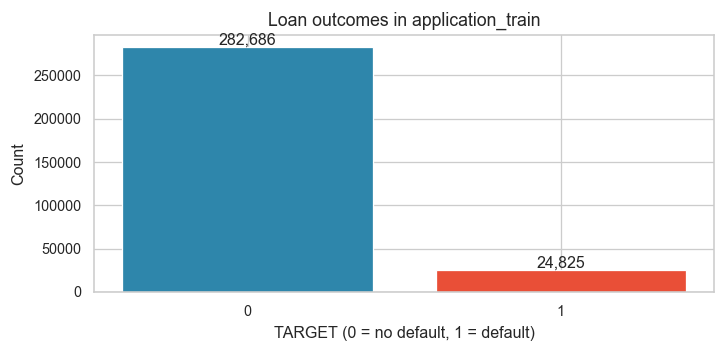

In [28]:
fig, ax = plt.subplots(figsize=(6.4, 3.15))
vc = df["TARGET"].value_counts().sort_index()
bars = ax.bar(vc.index.astype(str), vc.values, color=[ACCENT, ACCENT2], edgecolor="white", linewidth=0.8)
ax.set_xlabel("TARGET (0 = no default, 1 = default)")
ax.set_ylabel("Count")
ax.set_title("Loan outcomes in application_train")
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{int(b.get_height()):,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()



### Target distribution (proportion)


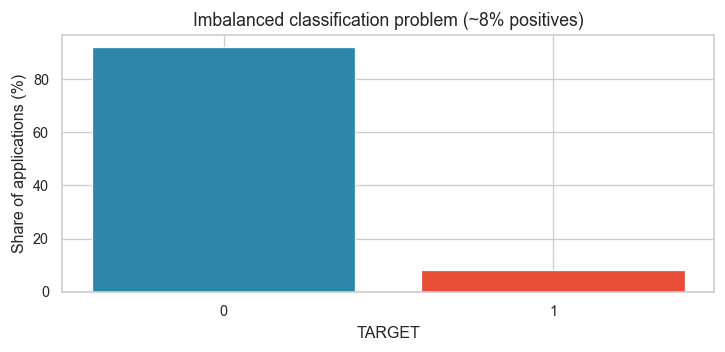

In [29]:
fig, ax = plt.subplots(figsize=(6.4, 3.15))
prop = df["TARGET"].value_counts(normalize=True).sort_index()
ax.bar(prop.index.astype(str), prop.values * 100, color=[ACCENT, ACCENT2], edgecolor="white")
ax.set_xlabel("TARGET")
ax.set_ylabel("Share of applications (%)")
ax.set_title("Imbalanced classification problem (~8% positives)")
plt.tight_layout()
plt.show()



### Missing values (top 16 columns)


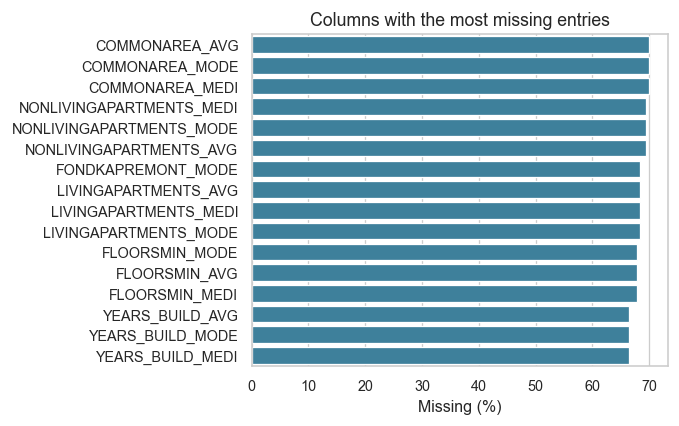

In [30]:
top_miss = missing_pct.head(16)
fig, ax = plt.subplots(figsize=(6.0, 3.8))
sns.barplot(x=top_miss.values, y=top_miss.index, ax=ax, color=ACCENT)
ax.set_xlabel("Missing (%)")
ax.set_ylabel("")
ax.set_title("Columns with the most missing entries")
plt.tight_layout()
plt.show()



### Distribution: `AMT_INCOME_TOTAL`


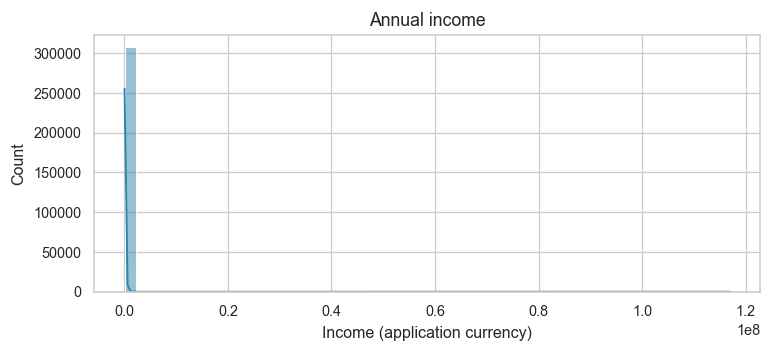

In [31]:
fig, ax = plt.subplots(figsize=(6.8, 3.15))
sns.histplot(df["AMT_INCOME_TOTAL"].dropna(), bins=55, kde=True, color=ACCENT, ax=ax, edgecolor="white")
ax.set_title("Annual income")
ax.set_xlabel("Income (application currency)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()



### Distribution: `AMT_CREDIT`


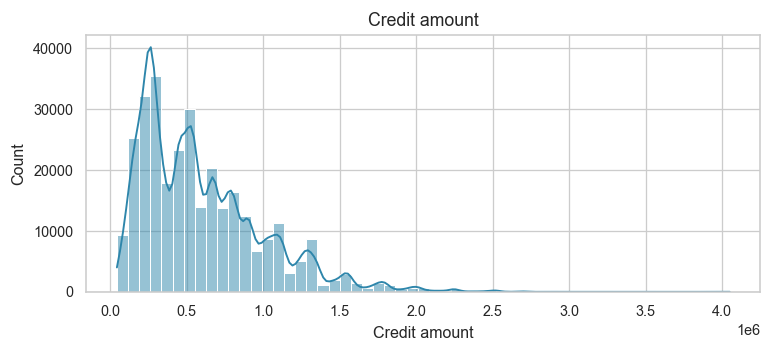

In [32]:
fig, ax = plt.subplots(figsize=(6.8, 3.15))
sns.histplot(df["AMT_CREDIT"].dropna(), bins=55, kde=True, color=ACCENT, ax=ax, edgecolor="white")
ax.set_title("Credit amount")
ax.set_xlabel("Credit amount")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()



### Distribution: `AMT_ANNUITY`


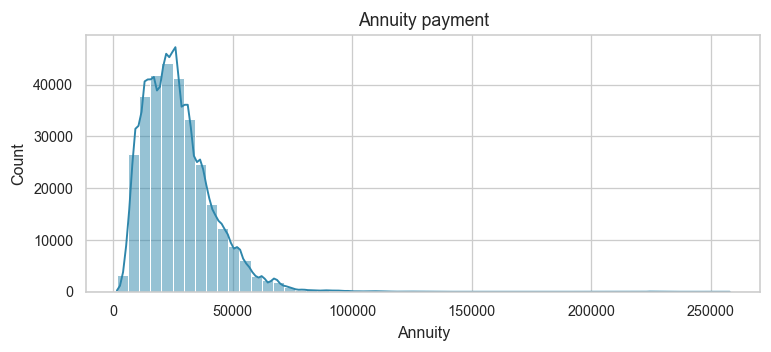

In [33]:
fig, ax = plt.subplots(figsize=(6.8, 3.15))
sns.histplot(df["AMT_ANNUITY"].dropna(), bins=55, kde=True, color=ACCENT, ax=ax, edgecolor="white")
ax.set_title("Annuity payment")
ax.set_xlabel("Annuity")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()



### `EXT_SOURCE_1` vs TARGET (density)


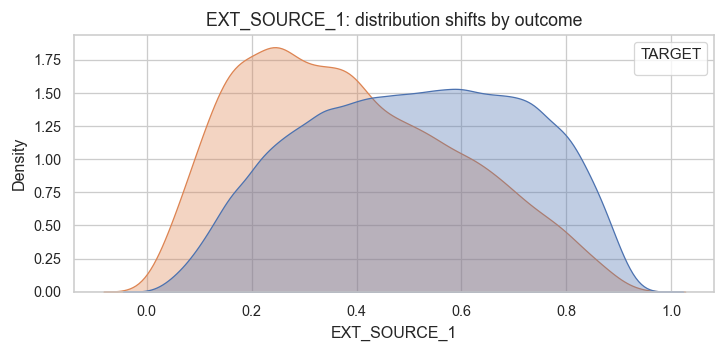

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 3.15))
sns.kdeplot(data=df, x="EXT_SOURCE_1", hue="TARGET", common_norm=False, fill=True, alpha=0.35, ax=ax)
ax.set_title("EXT_SOURCE_1: distribution shifts by outcome")
ax.set_xlabel("EXT_SOURCE_1")
handles, _labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Repaid (0)", "Default (1)"], title="TARGET")
plt.tight_layout()
plt.show()

 

### `EXT_SOURCE_2` vs TARGET (density)


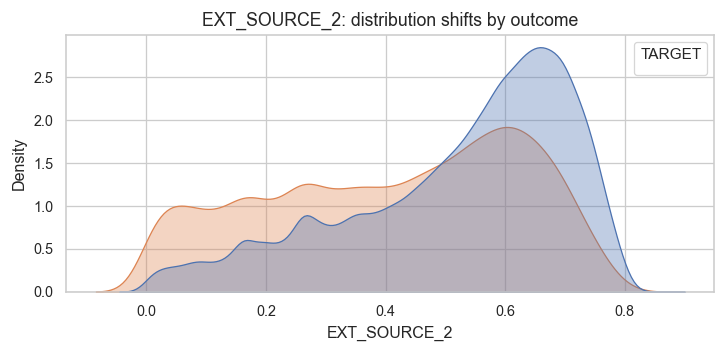

In [35]:
fig, ax = plt.subplots(figsize=(6.4, 3.15))
sns.kdeplot(data=df, x="EXT_SOURCE_2", hue="TARGET", common_norm=False, fill=True, alpha=0.35, ax=ax)
ax.set_title("EXT_SOURCE_2: distribution shifts by outcome")
ax.set_xlabel("EXT_SOURCE_2")
handles, _labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Repaid (0)", "Default (1)"], title="TARGET")
plt.tight_layout()
plt.show()



### `EXT_SOURCE_3` vs TARGET (density)


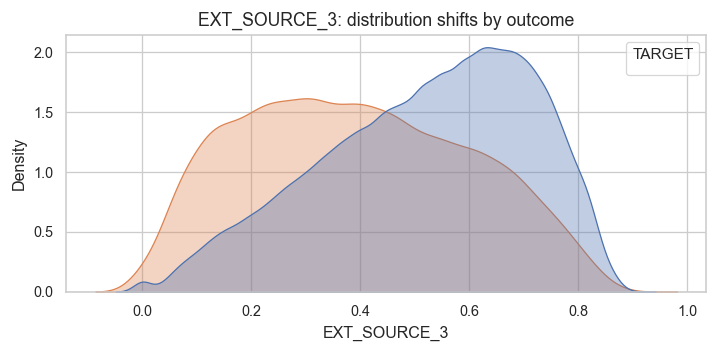

In [36]:
fig, ax = plt.subplots(figsize=(6.4, 3.15))
sns.kdeplot(data=df, x="EXT_SOURCE_3", hue="TARGET", common_norm=False, fill=True, alpha=0.35, ax=ax)
ax.set_title("EXT_SOURCE_3: distribution shifts by outcome")
ax.set_xlabel("EXT_SOURCE_3")
handles, _labels = ax.get_legend_handles_labels()
ax.legend(handles, ["Repaid (0)", "Default (1)"], title="TARGET")
plt.tight_layout()
plt.show()



## Feature engineering — design rationale

Features follow **four risk dimensions** on the **current application**:

1. **Capacity to pay** — income vs. recurring obligations; household load.
2. **Repayment stability** — employment tenure and age structure.
3. **Financial burden** — leverage and installment load relative to contract size (**including `CREDIT_TERM` ≈ credit / annuity**).
4. **External risk signals** — normalized `EXT_SOURCE` scores and aggregates.

Related tables contribute **only after** `groupby`/`agg` per `SK_ID_CURR`: bureau + bureau_balance, prior applications, installments, POS cash, credit card balances.



## Multi-table data: load, incremental AUC, full merge

**Leakage discipline:** aggregates use historic installments and balances linked to `SK_ID_CURR`; day-count sentinels (`365243`) are nulled before aggregation.

**Incremental protocol:** same preprocessing as `evaluate_models` — refit **Logistic Regression** (holdout + 5-fold mean) and **LightGBM** with early stopping after each merged block.

**Signal upgrades (no leakage):** multi-window slices — installments **`INST_W90/180/365`** (days); bureau / CC / POS **`W3–W13`** (~3–13 statement months; **W13 ≈ ~365d** horizon vs. **W12**); behavioral rates (**late pay**, **utilization >80% / >90%**, **DPD / delinquency presence**, **`PREV_HAS_REFUSAL`**), plus recency-weighted means — all aggregated **before** join. Validation: **gain pruning** + LightGBM refit. Production scores: **`N_FOLD_ENSEMBLE` stratified CV** LightGBMs, **average test predictions** (same pruned columns + preprocessor as validation).



In [37]:
# --- Load auxiliary tables (HomeCredit_columns_description.csv documents schema; all tables below are standard competition files.)
bureau = reduce_mem_usage(pd.read_csv(PATH_BUREAU))
bureau_balance = reduce_mem_usage(pd.read_csv(PATH_BUREAU_BALANCE))
previous_application = reduce_mem_usage(pd.read_csv(PATH_PREVIOUS_APPLICATION))
installments_payments = reduce_mem_usage(pd.read_csv(PATH_INSTALLMENTS))
POS_CASH_balance = reduce_mem_usage(pd.read_csv(PATH_POS_CASH))
credit_card_balance = reduce_mem_usage(pd.read_csv(PATH_CREDIT_CARD))


| | MB |
|---:|---:|
| Before | 472.8 |
| After | 409.0 |
| Reduction | 13.5% |

| | MB |
|---:|---:|
| Before | 1718.3 |
| After | 1431.9 |
| Reduction | 16.7% |

| | MB |
|---:|---:|
| Before | 1703.0 |
| After | 1588.3 |
| Reduction | 6.7% |

| | MB |
|---:|---:|
| Before | 830.4 |
| After | 493.1 |
| Reduction | 40.6% |

| | MB |
|---:|---:|
| Before | 1060.9 |
| After | 727.1 |
| Reduction | 31.5% |

| | MB |
|---:|---:|
| Before | 846.4 |
| After | 652.3 |
| Reduction | 22.9% |

In [38]:
aux_tables = dict(
    bureau=bureau,
    bureau_balance=bureau_balance,
    previous_application=previous_application,
    installments_payments=installments_payments,
    pos_cash_balance=POS_CASH_balance,
    credit_card_balance=credit_card_balance,
)

RUN_INCREMENTAL_STUDY = True


In [ ]:
if RUN_INCREMENTAL_STUDY:
    incremental_results = run_incremental_table_study(
        df,
        bureau=bureau,
        bureau_balance=bureau_balance,
        previous_application=previous_application,
        installments_payments=installments_payments,
        pos_cash_balance=POS_CASH_balance,
        credit_card_balance=credit_card_balance,
        random_state=RANDOM_STATE,
    )
    display(
        incremental_results.style.hide(axis="index")
        .set_caption(
            "Incremental ROC-AUC after each merged table (same holdout & encoders)"
        )
        .set_properties(**{"text-align": "left", "font-size": "11px"})
        .set_table_styles(
            [
                {
                    "selector": "th, td",
                    "props": [("padding", "3px 7px"), ("line-height", "1.3")],
                },
                {
                    "selector": "caption",
                    "props": [
                        ("font-size", "11px"),
                        ("font-weight", "600"),
                        ("caption-side", "top"),
                        ("padding", "0 0 4px 0"),
                    ],
                },
            ]
        )
    )


Training until validation scores don't improve for 120 rounds
Early stopping, best iteration is:
[808]	train's auc: 0.850778	valid's auc: 0.772111


In [ ]:
# Final training frame: ALL tables (`full` stage) + application-level engineered fields
merged_train = merge_stage(df.copy(), "full", **aux_tables)
merged_train = engineer_application_features(merged_train)


## Evaluation (validation)

Holdout metrics and early-stopping iteration inform the **full-data** LightGBM training round count and `scale_pos_weight`.



In [ ]:
validation_ev = evaluate_models(
    merged_train,
    random_state=RANDOM_STATE,
    ohe_max_categories=OHE_MAX_CATEGORIES,
    miss_drop_threshold=MISS_DROP_THRESHOLD,
    prune_bottom_frac=PRUNE_BOTTOM_FRAC,
)

_best_it = validation_ev["best_iteration"]
best_it = int(_best_it) if _best_it is not None else 500


In [ ]:
x_full, y_full, feature_names = dataframe_to_design_matrix(
    merged_train,
    ohe_max_categories=OHE_MAX_CATEGORIES,
    miss_drop_threshold=MISS_DROP_THRESHOLD,
)

X_train, X_val, y_train, y_val = train_test_split(
    x_full,
    y_full,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_full,
)

FEATURE_KEEP_IDX = validation_ev["feature_keep_indices"]
if FEATURE_KEEP_IDX is not None:
    X_train = X_train[:, FEATURE_KEEP_IDX]
    X_val = X_val[:, FEATURE_KEEP_IDX]
    feature_names = [feature_names[i] for i in FEATURE_KEEP_IDX]


In [ ]:
split_md = (
    f"| Set | Rows | Default rate |\n|:---|---:|---:|\n"
    f"| Train | {len(y_train):,} | {y_train.mean():.2%} |\n"
    f"| Validation | {len(y_val):,} | {y_val.mean():.2%} |"
)
display(Markdown(split_md))


## Modeling

**Logistic regression:** `StandardScaler` on train; **CV:** Stratified K-Fold on the training matrix (scaler inside folds).  
**LightGBM:** validation run above (`validation_ev`).  
**Random Forest:** bagged trees on the same stratified split for comparison.



In [ ]:
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr = scaler_lr.transform(X_val)

log_reg = LogisticRegression(
    max_iter=600,
    solver="liblinear",
    dual=False,
    C=0.1,
    random_state=RANDOM_STATE,
)
log_reg.fit(X_train_lr, y_train)
prob_val_lr = log_reg.predict_proba(X_val_lr)[:, 1]
auc_lr = roc_auc_score(y_val, prob_val_lr)



In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_aucs = []
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train), start=1):
    x_tr, x_va = X_train[tr_idx], X_train[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]
    sc = StandardScaler()
    x_tr_s = sc.fit_transform(x_tr)
    x_va_s = sc.transform(x_va)
    m = LogisticRegression(
        max_iter=600,
        solver="liblinear",
        dual=False,
        C=0.1,
        random_state=RANDOM_STATE,
    )
    m.fit(x_tr_s, y_tr)
    fold_aucs.append(roc_auc_score(y_va, m.predict_proba(x_va_s)[:, 1]))

mean_cv = float(np.mean(fold_aucs))
std_cv = float(np.std(fold_aucs))



In [ ]:
gbm_val = validation_ev["gbm"]
prob_val_lgb = gbm_val.predict(X_val, num_iteration=gbm_val.best_iteration)
auc_lgb = roc_auc_score(y_val, prob_val_lgb)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
prob_val_rf = rf.predict_proba(X_val)[:, 1]
auc_rf = roc_auc_score(y_val, prob_val_rf)



## Experiment summary


In [ ]:
results = pd.DataFrame(
    {
        "Stage": ["Interpretable baseline", "Boosted trees (validation)", "Bagged trees"],
        "Model": ["Logistic Regression", "LightGBM", "Random Forest"],
        "ROC-AUC": [f"{auc_lr:.4f}", f"{auc_lgb:.4f}", f"{auc_rf:.4f}"],
        "Insight": [
            "Scaled linear baseline on the encoded design matrix.",
            "LightGBM: early stopping, class weights, non-linear signal on aggregates.",
            "Random Forest: ensemble sanity-check vs boosting.",
        ],
    }
)
display(
    results.style.hide(axis="index")
    .set_caption("Experiments — stratified holdout")
    .set_properties(**{"text-align": "left", "font-size": "11px"})
    .set_table_styles(
        [
            {
                "selector": "th, td",
                "props": [("padding", "3px 7px"), ("line-height", "1.3")],
            },
            {
                "selector": "caption",
                "props": [
                    ("font-size", "11px"),
                    ("font-weight", "600"),
                    ("caption-side", "top"),
                    ("padding", "0 0 4px 0"),
                ],
            },
        ]
    )
)
display(
    Markdown(
        f"*LogReg 5-fold (train):* **{mean_cv:.4f}** ± **{std_cv:.4f}** · "
        f"*LightGBM (validation):* best iteration **{best_it}**, `scale_pos_weight` = **{validation_ev['scale_pos_weight']:.2f}**"
    )
)



## Final training pipeline

Fit **`DesignMatrixPreprocessor` on all labeled rows**, apply the **same gain-pruned columns** as validation (`FEATURE_KEEP_IDX`). Train **`N_FOLD_ENSEMBLE` stratified LightGBM models** with **`_lgb_binary_params`** (regularized): each fold gets its own **`scale_pos_weight`** on the training slice, **early stopping on the validation fold**, and **`best_iteration`** for predictions. **Submission scores** average fold-wise **test predictions** (no leakage). **`final_gbm`** keeps the **last fold booster** only for approximate feature-importance plots.



In [ ]:
prep_final = DesignMatrixPreprocessor(
    ohe_max_categories=OHE_MAX_CATEGORIES,
    miss_drop_threshold=MISS_DROP_THRESHOLD,
)
prep_final.fit(merged_train)

X_all = prep_final.X_train_
y_all = prep_final.y_

if FEATURE_KEEP_IDX is not None:
    X_all = X_all[:, FEATURE_KEEP_IDX]

if FEATURE_KEEP_IDX is not None:
    feature_names_final = [prep_final.feature_names_[i] for i in FEATURE_KEEP_IDX]
else:
    feature_names_final = list(prep_final.feature_names_)


In [ ]:
skf_full = StratifiedKFold(n_splits=N_FOLD_ENSEMBLE, shuffle=True, random_state=RANDOM_STATE)
kfold_lgb_models: list = []
oof_pred = np.zeros(len(y_all), dtype=np.float64)
fold_val_aucs = []

for fold, (tr_idx, va_idx) in enumerate(skf_full.split(X_all, y_all)):
    X_tr, X_va = X_all[tr_idx], X_all[va_idx]
    y_tr, y_va = y_all[tr_idx], y_all[va_idx]
    pos_f = (y_tr == 1).sum()
    neg_f = (y_tr == 0).sum()
    spw_f = neg_f / pos_f if pos_f else 1.0
    params_f = _lgb_binary_params(spw_f, RANDOM_STATE)
    dtr = lgb.Dataset(X_tr, label=y_tr)
    dva = lgb.Dataset(X_va, label=y_va, reference=dtr)
    gbm_f = lgb.train(
        params_f,
        dtr,
        num_boost_round=5000,
        valid_sets=[dva],
        valid_names=["valid"],
        callbacks=[
            lgb.early_stopping(stopping_rounds=120),
            lgb.log_evaluation(period=0),
        ],
    )
    kfold_lgb_models.append(gbm_f)
    p_va = gbm_f.predict(X_va, num_iteration=gbm_f.best_iteration)
    oof_pred[va_idx] = p_va
    fold_val_aucs.append(float(roc_auc_score(y_va, p_va)))

oof_auc = float(roc_auc_score(y_all, oof_pred))
final_gbm = kfold_lgb_models[-1]


In [ ]:
display(
    Markdown(
        f"**Stratified {N_FOLD_ENSEMBLE}-fold LightGBM** on full train · **OOF ROC-AUC ≈ {oof_auc:.4f}** · "
        f"per-fold valid AUC: {', '.join(f'{a:.4f}' for a in fold_val_aucs)}"
    )
)


## Submission generation (`application_test.csv`)

Apply **identical** merges, `engineer_application_features`, and **`prep_final.transform`**, then **average** the **`kfold_lgb_models`** test probabilities (`ensemble_test_preds`). Requires `application_test.csv` from the competition bundle (same folder as the other CSVs).



In [ ]:
if not os.path.isfile(PATH_TEST):
    raise FileNotFoundError(
        f"Missing {PATH_TEST}. Download it from the Kaggle competition dataset and place it in the notebook directory."
    )

df_test = pd.read_csv(PATH_TEST)
df_test = reduce_mem_usage(df_test, verbose=False)

sentinel_te = df_test["DAYS_EMPLOYED"] == 365243
df_test.loc[sentinel_te, "DAYS_EMPLOYED"] = np.nan


In [ ]:
merged_test = merge_stage(df_test, "full", **aux_tables)
merged_test = engineer_application_features(merged_test)

X_test = prep_final.transform(merged_test)
if FEATURE_KEEP_IDX is not None:
    X_test = X_test[:, FEATURE_KEEP_IDX]
assert X_test.shape[1] == X_all.shape[1]

ensemble_test_preds = np.column_stack(
    [m.predict(X_test, num_iteration=m.best_iteration) for m in kfold_lgb_models]
)
predictions = ensemble_test_preds.mean(axis=1)

submission = pd.DataFrame({"SK_ID_CURR": merged_test["SK_ID_CURR"], "TARGET": predictions})
submission.to_csv("submission.csv", index=False)

display(Markdown(f"Wrote **submission.csv** ({len(submission):,} rows)."))


## Interpretation — feature importance (CV LightGBM)

Approximate drivers using **gain importances** from the **last fold’s** booster (`final_gbm`). For a single global ranking, **permutation importance** or **mean gain across folds** could be added but is heavier to run.



In [ ]:
def feature_bucket(name: str) -> str:
    s = str(name).upper()
    if any(p in s for p in ("BURO_", "PREV_", "INST_", "POS_", "CC_", "BB_")):
        return "Subsidiary aggregates"
    if "EXT_SOURCE" in s or s.startswith("EXT_"):
        return "External scores"
    if any(k in s for k in ("AGE_YEARS", "EMPLOYMENT_", "DAYS_BIRTH", "DAYS_EMPLOYED")):
        return "Time-based"
    if (
        "RATIO" in s
        or "CREDIT_INCOME" in s
        or "ANNUITY_INCOME" in s
        or "ANNUITY_CREDIT" in s
        or "CHILDREN_RATIO" in s
    ):
        return "Ratios"
    if any(k in s for k in ("AMT_", "INCOME", "ANNUITY", "GOODS_PRICE", "CREDIT")) and "RATIO" not in s:
        return "Capacity"
    return "Other"


In [ ]:
importance = pd.Series(
    final_gbm.feature_importance(importance_type="gain"),
    index=feature_names_final,
).sort_values(ascending=False)

top15 = importance.head(15).rename("gain").reset_index().rename(columns={"index": "feature"})
top15["category"] = top15["feature"].map(feature_bucket)

cat_palette = {
    "Subsidiary aggregates": "#1B4332",
    "External scores": "#2E86AB",
    "Ratios": "#A23B72",
    "Time-based": "#F18F01",
    "Capacity": "#6A994E",
    "Other": "#888888",
}
plot_df = top15.iloc[::-1].reset_index(drop=True)
colors = plot_df["category"].map(lambda x: cat_palette.get(x, "#888888"))

fig, ax = plt.subplots(figsize=(6.2, 3.1))
ax.barh(plot_df["feature"], plot_df["gain"], color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Gain")
ax.set_title("Top 15 features (final LightGBM on full train) — by category")
handles = [
    plt.Rectangle((0, 0), 1, 1, color=cat_palette[k], label=k)
    for k in [
        "Subsidiary aggregates",
        "External scores",
        "Ratios",
        "Time-based",
        "Capacity",
        "Other",
    ]
    if k in top15["category"].values
]
ax.legend(handles=handles, title="Category", loc="lower right", frameon=True)
plt.tight_layout()
plt.show()


In [ ]:
display(
    plot_df.iloc[::-1][["feature", "category", "gain"]]
    .reset_index(drop=True)
    .style.hide(axis="index")
    .set_caption("Top 15 features (gain)")
    .format({"gain": "{:.4f}"})
    .set_properties(**{"text-align": "left", "font-size": "11px"})
    .set_table_styles(
        [
            {"selector": "th, td", "props": [("padding", "3px 7px"), ("line-height", "1.3")]},
            {
                "selector": "caption",
                "props": [
                    ("font-size", "11px"),
                    ("font-weight", "600"),
                    ("caption-side", "top"),
                    ("padding", "0 0 4px 0"),
                ],
            },
        ]
    )
)


**Interpretation:** **External scores** (`EXT_SOURCE_*`) typically rank highest — they summarize third-party creditworthiness. **Affordability ratios** (`ANNUITY_INCOME_RATIO`, `CREDIT_TERM`, debt-to-income style measures) capture payment stress. **Subsidiary aggregates** (`BURO_*`, `INST_*`, `CC_*`, …) inject behavioral and bureau history **after** principled aggregation, improving discrimination without leaking future labels.



## Validation discipline & reproducibility

**Incremental study:** each row refits models under the **same** encoding policy so AUCs are comparable.

**Submission path:** encoders and imputation medians come **only** from `merged_train` via `prep_final` — test rows never influence training statistics.

**Seeds:** `RANDOM_STATE` fixes splits inside `evaluate_models` and tree models.



## Conclusion

**What worked:** strong tree models on a wide engineered matrix; **`EXT_SOURCE_*`** and **capacity/ratio** features remain central; **aggregated subsidiary tables** add signal beyond the current application row.

**Production caution:** calibration for score cutoffs; monitor **external scores** and income cohorts over time.



## Next steps

Optional: K-fold stacking, hyperparameter search, or **probability calibration** on a held-out slice.

